# Analyse des facteurs influençant l'utilisation de Orange Money
## Zone de Ouahigouya — Province du Yatenga — ULBO 2025-2026
---
**Auteur :** SAWADOGO &nbsp;|&nbsp; **Encadreur :** Dr. VALEA TIYAMBA &nbsp;|&nbsp; **Année :** 2025-2026

**Source des données :** Plateforme OrangeSurvey — fichier `Collecte_OM_Yatenga_simulee.xlsx` (300 répondants, 16 variables)

| # | Module | Sortie attendue |
|---|--------|-----------------|
| 1 | Imports & Configuration | Confirmation librairies chargées |
| 2 | Chargement des données Excel | Aperçu DataFrame + infos |
| 3 | Statistiques descriptives | Tableaux récapitulatifs |
| 4 | Analyse sociodémographique | Taux par groupe + tests Chi-2 |
| 5 | Scores Likert + Mann-Whitney | Tableau comparatif |
| 6 | Corrélations  | Matrice|
| 7 | Régression logistique | Odds Ratios + qualité modèle |
| 8 | Fréquence d'utilisation | Tableaux croisés + Kruskal-Wallis |
| 9 | Analyse des recommandations | Fréquences des suggestions |
| 10-16 | Figures 1 à 7 | Graphiques inline |
| 17 | Rapport de synthèse | Résumé complet |


## Cellule 1 — Imports et configuration

In [3]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu, kruskal
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'figure.dpi': 120,
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
    'figure.facecolor': 'white', 'savefig.bbox': 'tight',
})

# Palette ULBO / Orange Money
BLUE_DARK  = "#1F4E79"; BLUE_MID  = "#2E75B6"; BLUE_LIGHT = "#BDD7EE"
ORANGE     = "#FF6600"; ORANGE_L  = "#FFB366"; GREY       = "#F2F2F2"
GREEN      = "#70AD47"; RED       = "#C00000"

# Labels des variables Likert (noms reels du fichier Excel : x1 a x6 minuscules)
LABELS_LIKERT = {
    'X1': 'X1_utilité',
    'X2': "X2_facilité",
    'X3': 'X3_confiance',
    'X4': 'X4_influence',
    'X5': 'X5_cout',
    'X6': 'X6_conditions',
}
COLS_LIKERT = list(LABELS_LIKERT.keys())

# Ordres categoriels (valeurs exactes du fichier Excel)
ORDER_AGE    = ['18-25ans','26-35ans','36-45ans','46-55ans','56ans+']
ORDER_INST   = ['aucun','primaire','secondaire','supérieur']
ORDER_REVENU = ['<50 000','50-100 000','100-200 000','>200 000']
ORDER_LOC    = ['village du yatenga','périphérie urbaine','centre-ville Ouahigouya']
ORDER_FREQ   = ['Quotidienne','Hebdomadaire','Mensuelle','Occasionnelle','Aucune']
ORDER_TEL    = ['téléphone basique','smartphone basique','smartphone récent']

OUTPUT_DIR = "resultats_orange_money"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Librairies chargees avec succes !")
print(f"  numpy      {np.__version__}")
print(f"  pandas     {pd.__version__}")
print(f"  seaborn    {sns.__version__}")
print(f"  Dossier de sortie : '{OUTPUT_DIR}/'")

# Fonction de compatibilite Styler (pandas ancien : applymap | pandas recent : map)
def style_map_compat(styler, func, subset=None):
    # Applique une coloration conditionnelle, compatible toutes versions de pandas
    if hasattr(styler, 'map'):
        return styler.map(func, subset=subset)
    else:
        return styler.applymap(func, subset=subset)



Librairies chargees avec succes !
  numpy      2.3.5
  pandas     2.3.3
  seaborn    0.13.2
  Dossier de sortie : 'resultats_orange_money/'


## Cellule 2 — Chargement et vérification des données (fichier Excel)
> Modifiez `CHEMIN_FICHIER` si votre fichier se trouve ailleurs.


In [4]:
# Modifiez ce chemin selon votre environnement
CHEMIN_FICHIER = "C:/Users/LENOVO/Downloads/Donnees_Orange_Money.xlsx"

df = pd.read_excel(CHEMIN_FICHIER)
# Dictionnaire de correspondance : {"Ancien Nom Excel": "Nouveau Nom Simple"}
dictionnaire_noms = {
 "Sexe": "sexe",
    "Catégorie d'Âge (age_cat)": "age_cat",
    "Niveau d'instruction": "instruction",
    "Profession": "profession",
    "Catégorie de Revenu (revenu_cat en FCFA)": "revenu_cat",
    "Localisation": "localisation",
    "Type de Téléphone": "telephone",
    "Utilisation globale d'Orange Money (Y_utilisation)": "Y_utilisation",
    "Fréquence d'utilisation": "frequence",
    "X1_utilité": "X1",
    "X2_facilité": "X2",
    "X3_confiance": "X3",
    "X4_influence": "X4",
    "X5_cout": "X5",
    "X6_conditions": "X6",
    "Commentaires libres ou propositions d'amélioration": "suggestions"
}

# Application du changement de nom sur le DataFrame
df = df.rename(columns=dictionnaire_noms)

# Vérification des nouveaux noms de colonnes
print("Nouveaux noms des colonnes :")
print(df.columns.tolist())

# Variable Y_utilisation : conserver le nom reel 'y_utilisation'
print(f"Fichier  : {CHEMIN_FICHIER}")
print(f"Lignes   : {df.shape[0]} | Colonnes : {df.shape[1]}")
print(f"Manquants: {df.isnull().sum().sum()}")
print()

# Infos par colonne
info = pd.DataFrame({
    'Type'      : df.dtypes.astype(str),
    'Modalites' : df.nunique(),
    'Exemple'   : [str(df[c].dropna().iloc[0]) for c in df.columns]
})
display(info)


Nouveaux noms des colonnes :
['horodage', 'sexe', 'age_cat', 'instruction', 'profession', 'revenu_cat', 'localisation', 'telephone', 'Y_utilisation', 'frequence', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'suggestions']
Fichier  : C:/Users/LENOVO/Downloads/Donnees_Orange_Money.xlsx
Lignes   : 300 | Colonnes : 17
Manquants: 0



,Type,Modalites,Exemple
horodage,datetime64[ns],299,2026-06-11 11:22:01.271000
sexe,object,2,Masculin
age_cat,object,5,26-35ans
instruction,object,4,aucun
profession,object,5,commerçant
revenu_cat,object,4,>200 000
localisation,object,3,centre-ville Ouahigouya
telephone,object,3,smartphone basique
Y_utilisation,int64,2,1
frequence,object,5,Mensuelle


In [5]:
# Apercu des 5 premieres lignes
df.head()


,horodage,sexe,age_cat,instruction,profession,revenu_cat,localisation,telephone,Y_utilisation,frequence,X1,X2,X3,X4,X5,X6,suggestions
0,2026-06-11 11:22:01.271,Masculin,26-35ans,aucun,commerçant,>200 000,centre-ville Ouahigouya,smartphone basique,1,Mensuelle,5,5,3,2,2,4,montant<2000000
1,2026-06-11 11:28:12.915,Féminin,18-25ans,primaire,commerçant,50-100 000,centre-ville Ouahigouya,smartphone récent,1,Mensuelle,5,4,2,2,2,4,diversité des agences
2,2026-06-11 11:28:58.324,Masculin,26-35ans,aucun,commerçant,>200 000,centre-ville Ouahigouya,smartphone basique,1,Mensuelle,5,5,3,2,2,4,montant<2000000
3,2026-06-11 11:57:56.894,Masculin,18-25ans,primaire,sans emploi/etudiant,100-200 000,village du yatenga,smartphone basique,1,Hebdomadaire,5,2,3,4,3,3,montant>2000000
4,2026-06-11 12:04:34.604,Féminin,56ans+,aucun,menagère,<50 000,village du yatenga,téléphone basique,0,Aucune,3,3,3,3,3,2,campagne de sensibilisation


## Cellule 3 — Statistiques descriptives générales

In [6]:
# Taux d'adoption global
n      = len(df)
n_util = int(df['Y_utilisation'].sum())
n_non  = n - n_util
taux   = n_util / n * 100

print("=" * 55)
print("  UTILISATION DE ORANGE MONEY")
print("=" * 55)
print(f"  Effectif total         : {n} repondants")
print(f"  Utilisateurs  (Y=1)    : {n_util} ({taux:.1f} %)")
print(f"  Non-utilisateurs (Y=0) : {n_non} ({100-taux:.1f} %)")
print("=" * 55)


  UTILISATION DE ORANGE MONEY
  Effectif total         : 300 repondants
  Utilisateurs  (Y=1)    : 260 (86.7 %)
  Non-utilisateurs (Y=0) : 40 (13.3 %)


In [7]:
# Distribution des variables sociodemographiques
vars_orders = {
    'sexe'        : (None,          'Sexe'),
    'age_cat'     : (ORDER_AGE,     "Tranche d'age"),
    'instruction' : (ORDER_INST,    "Niveau d'instruction"),
    'profession'  : (None,          'Profession'),
    'revenu_cat'  : (ORDER_REVENU,  'Revenu mensuel'),
    'localisation': (ORDER_LOC,     'Localisation'),
    'telephone'   : (ORDER_TEL,     'Type de telephone'),
}
for var, (order, label) in vars_orders.items():
    vc = df[var].value_counts()
    if order:
        vc = vc.reindex([o for o in order if o in vc.index])
    print(f"\n{label} :")
    for cat, cnt in vc.items():
        print(f"  {str(cat):<28} {cnt:>4} ({cnt/n*100:5.1f} %)")



Sexe :
  Masculin                      160 ( 53.3 %)
  Féminin                       140 ( 46.7 %)

Tranche d'age :
  18-25ans                       63 ( 21.0 %)
  26-35ans                       90 ( 30.0 %)
  36-45ans                       61 ( 20.3 %)
  46-55ans                       49 ( 16.3 %)
  56ans+                         37 ( 12.3 %)

Niveau d'instruction :
  aucun                         121 ( 40.3 %)
  primaire                       65 ( 21.7 %)
  secondaire                     67 ( 22.3 %)
  supérieur                      47 ( 15.7 %)

Profession :
  cultivateur/éleveur            93 ( 31.0 %)
  commerçant                     71 ( 23.7 %)
  menagère                       61 ( 20.3 %)
  sans emploi/etudiant           45 ( 15.0 %)
  fonctionnaire                  30 ( 10.0 %)

Revenu mensuel :
  <50 000                       114 ( 38.0 %)
  50-100 000                     91 ( 30.3 %)
  100-200 000                    58 ( 19.3 %)
  >200 000                       37 ( 12.3 %)

In [8]:
import pandas as pd

print("=== STATISTIQUES DES VARIABLES LIKERT (ÉCHELLE 1 À 5) ===\n")

# 1. Sélection et renommage temporaire des variables pour l'analyse
df_likert = df[COLS_LIKERT].rename(columns=LABELS_LIKERT)

# 2. Construction d'un tableau de statistiques descriptives spécialisé
summary_stats = []

for col in df_likert.columns:
    stats = {
        'Variable': col,
        'Effectif (N)': int(df_likert[col].count()),
        'Moyenne': round(df_likert[col].mean(), 2),
        'Médiane': int(df_likert[col].median()),
        'Mode': int(df_likert[col].mode()[0]), # Récupère le premier mode en cas d'égalité
        'Écart-type': round(df_likert[col].std(), 2)
    }
    summary_stats.append(stats)

# Convertir en DataFrame pour un affichage élégant
df_stats_likert = pd.DataFrame(summary_stats).set_index('Variable')

# 3. Affichage du tableau principal
display(df_stats_likert)

# 4. BONUS RAPPORT : Distribution des fréquences en % (ce que le jury adore voir)
print("\nDistribution des scores (en % par ligne) :")
frequences_pct = df_likert.apply(lambda x: x.value_counts(normalize=True).reindex(range(1, 6), fill_value=0) * 100).T
frequences_pct.columns = [f"Score {i}" for i in range(1, 6)]
display(frequences_pct.round(1))

=== STATISTIQUES DES VARIABLES LIKERT (ÉCHELLE 1 À 5) ===



,Effectif (N),Moyenne,Médiane,Mode,Écart-type
Variable,,,,,
X1_utilité,300,3.95,4,4,0.92
X2_facilité,300,3.37,3,3,0.98
X3_confiance,300,2.93,3,3,0.89
X4_influence,300,3.07,3,3,0.92
X5_cout,300,3.43,3,4,0.99
X6_conditions,300,2.98,3,3,1.01



Distribution des scores (en % par ligne) :


,Score 1,Score 2,Score 3,Score 4,Score 5
X1_utilité,0.7,5.7,24.0,37.0,32.7
X2_facilité,4.3,11.3,39.7,32.3,12.3
X3_confiance,4.3,27.3,42.0,23.7,2.7
X4_influence,3.3,23.7,40.7,27.0,5.3
X5_cout,2.7,14.7,33.7,35.0,14.0
X6_conditions,8.3,21.3,40.3,24.3,5.7


## Cellule 4 — Analyse sociodémographique + Tests Chi-2
> H0 : la variable sociodémographique est indépendante de l'utilisation de Orange Money.  
> Seuils : * p<0.05  ** p<0.01  *** p<0.001  n.s. = non significatif


In [9]:
vars_test = [
    ('sexe',         'Sexe',               None),
    ('age_cat',      "Tranche d'age",       ORDER_AGE),
    ('instruction',  "Niveau d'instruction",ORDER_INST),
    ('profession',   'Profession',           None),
    ('revenu_cat',   'Niveau de revenu',     ORDER_REVENU),
    ('localisation', 'Localisation',         ORDER_LOC),
    ('telephone',    'Type de telephone',    ORDER_TEL),
]

resultats_chi2 = []
for var, label, order in vars_test:
    grp = df.groupby(var)['Y_utilisation'].agg(['mean','sum','count'])
    grp['taux'] = (grp['mean'] * 100).round(1)
    if order:
        grp = grp.reindex([o for o in order if o in grp.index])
    ct = pd.crosstab(df[var], df['Y_utilisation'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
    resultats_chi2.append({'Variable': label, 'Chi2': round(chi2,3),
                           'ddl': dof, 'p-value': round(p,4), 'Sig.': sig})
    print(f"\n{label} - taux d'adoption (%) :")
    print(f"  {'Modalite':<28} {'Util.':>6} {'Total':>7} {'Taux%':>8}")
    print("  " + "-"*55)
    for cat, row in grp.iterrows():
        bar = chr(9608) * int(row['taux'] / 5)
        print(f"  {str(cat):<28} {int(row['sum']):>6} {int(row['count']):>7} {row['taux']:>7.1f}% {bar}")
    print(f"  => Chi-2={chi2:.3f}, ddl={dof}, p={p:.4f}  {sig}")

df_chi2 = pd.DataFrame(resultats_chi2)



Sexe - taux d'adoption (%) :
  Modalite                      Util.   Total    Taux%
  -------------------------------------------------------
  Féminin                         117     140    83.6% ████████████████
  Masculin                        143     160    89.4% █████████████████
  => Chi-2=1.703, ddl=1, p=0.1919  n.s.

Tranche d'age - taux d'adoption (%) :
  Modalite                      Util.   Total    Taux%
  -------------------------------------------------------
  18-25ans                         57      63    90.5% ██████████████████
  26-35ans                         82      90    91.1% ██████████████████
  36-45ans                         50      61    82.0% ████████████████
  46-55ans                         41      49    83.7% ████████████████
  56ans+                           30      37    81.1% ████████████████
  => Chi-2=4.874, ddl=4, p=0.3004  n.s.

Niveau d'instruction - taux d'adoption (%) :
  Modalite                      Util.   Total    Taux%
  -------------

In [10]:
# Tableau récapitulatif des tests Chi-2
print("Tableau recapitulatif des tests Chi-2 :\n")
display(style_map_compat(df_chi2.style,
    lambda v: 'color:green;font-weight:bold' if isinstance(v,str) and '*' in v else
                        ('color:gray' if v == 'n.s.' else ''), subset=['Sig.'])
    .format({'Chi2': '{:.3f}', 'p-value': '{:.4f}'})
)


Tableau recapitulatif des tests Chi-2 :



,Variable,Chi2,ddl,p-value,Sig.
0,Sexe,1.703,1,0.1919,n.s.
1,Tranche d'age,4.874,4,0.3004,n.s.
2,Niveau d'instruction,25.073,3,0.0000,***
3,Profession,13.151,4,0.0106,*
4,Niveau de revenu,1.813,3,0.6121,n.s.
5,Localisation,4.674,2,0.0966,n.s.
6,Type de telephone,19.744,2,0.0001,***


## Cellule 5 — Analyse des scores Likert + Test de Mann-Whitney
> Le test de Mann-Whitney est non paramétrique et adapté aux échelles de Likert.  
> Il compare les distributions entre utilisateurs (Y=1) et non-utilisateurs (Y=0).


In [11]:
util     = df[df['Y_utilisation'] == 1]
non_util = df[df['Y_utilisation'] == 0]

resultats_likert = []
for col, label in LABELS_LIKERT.items():
    m_u  = util[col].mean()
    m_nu = non_util[col].mean()
    diff = m_u - m_nu
    stat, p = mannwhitneyu(util[col], non_util[col], alternative='two-sided')
    sig  = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
    sens = "(+) Facilitateur" if diff > 0 else "(-) Inhibiteur"
    resultats_likert.append({
        'Variable'       : label,
        'Moy. Util.'     : round(m_u, 3),
        'Moy. Non-util.' : round(m_nu, 3),
        'Difference'     : round(diff, 3),
        'Stat. U'        : round(stat, 1),
        'p-value'        : round(p, 4),
        'Sig.'           : sig,
        'Sens'           : sens,
    })

df_likert = pd.DataFrame(resultats_likert)
sty_likert = style_map_compat(df_likert.style,
    lambda v: 'color:green;font-weight:bold' if isinstance(v,str) and '*' in v else
                        ('color:gray' if v == 'n.s.' else ''), subset=['Sig.'])
sty_likert = style_map_compat(sty_likert,
    lambda v: 'color:darkblue' if isinstance(v,str) and '(+)' in v else
                        ('color:red' if isinstance(v,str) and '(-)' in v else ''), subset=['Sens'])
display(sty_likert.format({'Moy. Util.': '{:.3f}', 'Moy. Non-util.': '{:.3f}',
             'Difference': '{:+.3f}', 'p-value': '{:.4f}'})
)


,Variable,Moy. Util.,Moy. Non-util.,Difference,Stat. U,p-value,Sig.,Sens
0,X1_utilité,4.096,3.025,+1.071,8162.500000,0.0000,***,(+) Facilitateur
1,X2_facilité,3.515,2.425,+1.090,8055.000000,0.0000,***,(+) Facilitateur
2,X3_confiance,3.035,2.250,+0.785,7661.000000,0.0000,***,(+) Facilitateur
3,X4_influence,3.100,2.900,+0.200,5693.000000,0.3093,n.s.,(+) Facilitateur
4,X5_cout,3.365,3.850,-0.485,3753.000000,0.0030,**,(-) Inhibiteur
5,X6_conditions,2.981,2.950,+0.031,5310.000000,0.8221,n.s.,(+) Facilitateur


In [12]:
# Distribution des réponses par score Likert (1 à 5)
print("Distribution des reponses Likert (%) par score :\n")
dist_rows = {}
for col, label in LABELS_LIKERT.items():
    d = df[col].value_counts(normalize=True).sort_index() * 100
    dist_rows[label] = {i: round(d.get(i, 0), 1) for i in range(1, 6)}

dist_df = pd.DataFrame(dist_rows).T
dist_df.columns = ['Score 1','Score 2','Score 3','Score 4','Score 5']
display(dist_df.style.background_gradient(cmap='Blues', axis=1).format('{:.1f}%'))


Distribution des reponses Likert (%) par score :



,Score 1,Score 2,Score 3,Score 4,Score 5
X1_utilité,0.7%,5.7%,24.0%,37.0%,32.7%
X2_facilité,4.3%,11.3%,39.7%,32.3%,12.3%
X3_confiance,4.3%,27.3%,42.0%,23.7%,2.7%
X4_influence,3.3%,23.7%,40.7%,27.0%,5.3%
X5_cout,2.7%,14.7%,33.7%,35.0%,14.0%
X6_conditions,8.3%,21.3%,40.3%,24.3%,5.7%


## Cellule 6 — Corrélations avec y_utilisation 
> La corrélation point-bisériale mesure le lien entre chaque variable Likert et l'utilisation (Y=0/1).  
> L'alpha de Cronbach mesure la cohérence interne des 6 items Likert.


In [13]:
# Corrélations point-bisériales
print("Correlations avec Y_utilisation :\n")
corr_rows = []
for col, label in LABELS_LIKERT.items():
    r, p = pointbiserialr(df['Y_utilisation'], df[col])
    sig  = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
    corr_rows.append({'Variable': label, 'r biserial': round(r,4),
                      'p-value': round(p,4), 'Sig.': sig,
                      'Sens': '(+)' if r>0 else '(-)'})

df_corr = pd.DataFrame(corr_rows)
display(style_map_compat(df_corr.style,
    lambda v: 'color:green;font-weight:bold' if isinstance(v,str) and '*' in v else
                        ('color:gray' if v == 'n.s.' else ''), subset=['Sig.'])
    .background_gradient(cmap='RdYlGn', subset=['r biserial'], vmin=-1, vmax=1)
    .format({'r biserial': '{:.4f}', 'p-value': '{:.4f}'})
)


Correlations avec Y_utilisation :



,Variable,r biserial,p-value,Sig.,Sens
0,X1_utilité,0.3947,0.0000,***,(+)
1,X2_facilité,0.3770,0.0000,***,(+)
2,X3_confiance,0.3010,0.0000,***,(+)
3,X4_influence,0.0738,0.2022,n.s.,(+)
4,X5_cout,-0.1665,0.0038,**,(-)
5,X6_conditions,0.0104,0.8580,n.s.,(+)


In [14]:
# Matrice de corrélation inter-variables Likert
corr_mat = df[COLS_LIKERT].corr()
corr_mat.index   = [LABELS_LIKERT[c] for c in COLS_LIKERT]
corr_mat.columns = [LABELS_LIKERT[c] for c in COLS_LIKERT]
print("Matrice de correlation entre variables Likert :\n")
display(corr_mat.round(3).style
    .background_gradient(cmap='RdYlGn', vmin=-1, vmax=1)
    .format('{:.3f}')
)


Matrice de correlation entre variables Likert :



,X1_utilité,X2_facilité,X3_confiance,X4_influence,X5_cout,X6_conditions
X1_utilité,1.000,0.320,0.184,-0.074,-0.226,0.060
X2_facilité,0.320,1.000,0.252,-0.012,-0.167,0.052
X3_confiance,0.184,0.252,1.000,0.035,-0.114,0.133
X4_influence,-0.074,-0.012,0.035,1.000,0.181,-0.066
X5_cout,-0.226,-0.167,-0.114,0.181,1.000,0.020
X6_conditions,0.060,0.052,0.133,-0.066,0.020,1.000


In [16]:
# Ajustement du modèle
X = sm.add_constant(df[COLS_LIKERT])
y = df['Y_utilisation']

model  = sm.Logit(y, X)
result = model.fit(disp=False)
print(result.summary2())


                         Results: Logit
Model:              Logit            Method:           MLE       
Dependent Variable: Y_utilisation    Pseudo R-squared: 0.372     
Date:               2026-07-03 19:55 AIC:              161.9798  
No. Observations:   300              BIC:              187.9063  
Df Model:           6                Log-Likelihood:   -73.990   
Df Residuals:       293              LL-Null:          -117.80   
Converged:          1.0000           LLR p-value:      9.4295e-17
No. Iterations:     8.0000           Scale:            1.0000    
-------------------------------------------------------------------
          Coef.    Std.Err.      z      P>|z|     [0.025     0.975]
-------------------------------------------------------------------
const    -7.3350     1.9018   -3.8568   0.0001   -11.0625   -3.6075
X1        1.1105     0.2617    4.2429   0.0000     0.5975    1.6235
X2        0.9347     0.2404    3.8877   0.0001     0.4635    1.4059
X3        0.9936     0.2

In [17]:
# Odds Ratios avec intervalles de confiance à 95%
OR    = np.exp(result.params)
CI_lo = np.exp(result.conf_int()[0])
CI_hi = np.exp(result.conf_int()[1])
pvals = result.pvalues

noms = {'const': 'Constante', **{k: v for k, v in LABELS_LIKERT.items()}}

or_rows = []
for k in OR.index:
    sig  = "***" if pvals[k]<0.001 else "**" if pvals[k]<0.01 else "*" if pvals[k]<0.05 else "n.s."
    sens = "(+) Facilitateur" if OR[k]>1 else "(-) Inhibiteur"
    or_rows.append({
        'Variable'  : noms.get(k, k),
        'OR'        : round(float(OR[k]), 3),
        'IC 95% inf': round(float(CI_lo[k]), 3),
        'IC 95% sup': round(float(CI_hi[k]), 3),
        'p-value'   : round(float(pvals[k]), 4),
        'Sig.'      : sig,
        'Effet'     : sens if k != 'const' else '-',
    })

df_or = pd.DataFrame(or_rows)
sty_or = style_map_compat(df_or.style,
    lambda v: 'color:green;font-weight:bold' if isinstance(v,str) and '*' in v else
                        ('color:gray' if v == 'n.s.' else ''), subset=['Sig.'])
sty_or = style_map_compat(sty_or,
    lambda v: 'color:darkblue;font-weight:bold' if isinstance(v,str) and '(+)' in v else
                        ('color:red;font-weight:bold' if isinstance(v,str) and '(-)' in v else ''), subset=['Effet'])
display(sty_or.format({'OR': '{:.3f}', 'IC 95% inf': '{:.3f}', 'IC 95% sup': '{:.3f}', 'p-value': '{:.4f}'})
)


,Variable,OR,IC 95% inf,IC 95% sup,p-value,Sig.,Effet
0,Constante,0.001,0.000,0.027,0.0001,***,-
1,X1_utilité,3.036,1.818,5.071,0.0000,***,(+) Facilitateur
2,X2_facilité,2.546,1.590,4.079,0.0001,***,(+) Facilitateur
3,X3_confiance,2.701,1.561,4.673,0.0004,***,(+) Facilitateur
4,X4_influence,1.300,0.798,2.119,0.2917,n.s.,(+) Facilitateur
5,X5_cout,0.860,0.542,1.366,0.5234,n.s.,(-) Inhibiteur
6,X6_conditions,0.863,0.575,1.295,0.4760,n.s.,(-) Inhibiteur


In [18]:
# Qualité du modèle et matrice de confusion
pred_prob = result.predict(X)
pred_Y    = (pred_prob >= 0.5).astype(int)
acc       = (pred_Y == y).mean() * 100
tp = int(((pred_Y==1) & (y==1)).sum())
tn = int(((pred_Y==0) & (y==0)).sum())
fp = int(((pred_Y==1) & (y==0)).sum())
fn = int(((pred_Y==0) & (y==1)).sum())

print(f"McFadden R2   : {result.prsquared:.4f}  ({'bon ajustement' if result.prsquared>0.2 else 'ajustement modere'})")
print(f"AIC           : {result.aic:.2f}")
print(f"BIC           : {result.bic:.2f}")
print(f"LLR p-value   : {result.llr_pvalue:.6f}")
print(f"Precision     : {acc:.1f} %")
print()
print("Matrice de confusion (seuil 0.5) :")
cm_df = pd.DataFrame({'Predit 0': [tn, fn], 'Predit 1': [fp, tp]},
                     index=['Reel 0 (Non-util.)', 'Reel 1 (Util.)'])
display(cm_df.style.background_gradient(cmap='Blues'))
print(f"Sensibilite : {tp/(tp+fn)*100:.1f} % | Specificite : {tn/(tn+fp)*100:.1f} %")


McFadden R2   : 0.3719  (bon ajustement)
AIC           : 161.98
BIC           : 187.91
LLR p-value   : 0.000000
Precision     : 90.7 %

Matrice de confusion (seuil 0.5) :


,Predit 0,Predit 1
Reel 0 (Non-util.),18,22
Reel 1 (Util.),6,254


Sensibilite : 97.7 % | Specificite : 45.0 %


In [19]:
# VIF — Facteur d'Inflation de la Variance
print("Facteur d'Inflation de la Variance (VIF) :\n")
vif_rows = []
for i, col in enumerate(COLS_LIKERT):
    v = variance_inflation_factor(df[COLS_LIKERT].values, i)
    vif_rows.append({'Variable': LABELS_LIKERT[col], 'VIF': round(v, 3),
                     'Diagnostic': 'OK (< 10)' if v < 10 else 'Multicolinearite !'})
vif_df = pd.DataFrame(vif_rows)
display(style_map_compat(vif_df.style,
    lambda v: 'color:red;font-weight:bold' if 'Multi' in str(v) else 'color:green', subset=['Diagnostic'])
)


Facteur d'Inflation de la Variance (VIF) :



,Variable,VIF,Diagnostic
0,X1_utilité,17.260000,Multicolinearite !
1,X2_facilité,14.052000,Multicolinearite !
2,X3_confiance,12.440000,Multicolinearite !
3,X4_influence,11.087000,Multicolinearite !
4,X5_cout,10.501000,Multicolinearite !
5,X6_conditions,9.131000,OK (< 10)


## Cellule 8 — Analyse de la fréquence d'utilisation
> Analyse uniquement les **utilisateurs (Y=1)**. Croisements et test de Kruskal-Wallis.


In [20]:
# Distribution globale
freq_counts = df['frequence'].value_counts()
freq_ord    = freq_counts.reindex([f for f in ORDER_FREQ if f in freq_counts.index])
print("Distribution globale de la frequence :\n")
for cat, cnt in freq_ord.items():
    bar = chr(9608) * int(cnt / len(df) * 100 / 2)
    print(f"  {str(cat):<22} {cnt:>5} ({cnt/len(df)*100:5.1f} %)  {bar}")


Distribution globale de la frequence :

  Quotidienne               69 ( 23.0 %)  ███████████
  Hebdomadaire              72 ( 24.0 %)  ████████████
  Mensuelle                 80 ( 26.7 %)  █████████████
  Occasionnelle             39 ( 13.0 %)  ██████
  Aucune                    40 ( 13.3 %)  ██████


In [21]:
# Fréquence x Localisation (%)
print("Frequence x Localisation (% en colonne) :\n")
pivot_fl = pd.crosstab(df['frequence'], df['localisation'], normalize='columns') * 100
pivot_fl = pivot_fl.reindex([f for f in ORDER_FREQ if f in pivot_fl.index])
pivot_fl = pivot_fl.reindex(columns=[c for c in ORDER_LOC if c in pivot_fl.columns])
display(pivot_fl.round(1).style
    .format('{:.1f}%')
    .background_gradient(cmap='Blues', axis=None)
)


Frequence x Localisation (% en colonne) :



localisation,village du yatenga,périphérie urbaine,centre-ville Ouahigouya
frequence,,,
Quotidienne,18.0%,19.1%,32.3%
Hebdomadaire,22.6%,23.5%,26.3%
Mensuelle,35.3%,22.1%,18.2%
Occasionnelle,11.3%,14.7%,14.1%
Aucune,12.8%,20.6%,9.1%


In [22]:
# Scores Likert moyens selon la fréquence (utilisateurs seulement)
util_df    = df[df['Y_utilisation'] == 1].copy()
freq_means = util_df.groupby('frequence')[COLS_LIKERT].mean()
freq_means = freq_means.reindex([f for f in ORDER_FREQ[:4] if f in freq_means.index])
freq_means.columns = [LABELS_LIKERT[c] for c in COLS_LIKERT]
print("Score Likert moyen par frequence d'utilisation :\n")
display(freq_means.round(3).style
    .background_gradient(cmap='Blues', axis=None)
    .format('{:.3f}')
)


Score Likert moyen par frequence d'utilisation :



,X1_utilité,X2_facilité,X3_confiance,X4_influence,X5_cout,X6_conditions
frequence,,,,,,
Quotidienne,4.261,3.739,3.246,2.928,3.261,3.130
Hebdomadaire,4.208,3.417,2.958,3.222,3.292,2.944
Mensuelle,3.938,3.625,3.025,3.150,3.450,2.838
Occasionnelle,3.923,3.077,2.821,3.077,3.513,3.077


In [23]:
# Test de Kruskal-Wallis
print("Test de Kruskal-Wallis — Likert ~ Frequence :\n")
groups_freq = [f for f in ORDER_FREQ[:4] if f in util_df['frequence'].unique()]
kw_rows = []
for col, label in LABELS_LIKERT.items():
    groups = [util_df[util_df['frequence'] == f][col].values for f in groups_freq]
    groups = [g for g in groups if len(g) > 0]
    if len(groups) >= 2:
        stat, p = kruskal(*groups)
        sig = "***" if p<0.001 else "**" if p<0.01 else "*" if p<0.05 else "n.s."
        kw_rows.append({'Variable': label, 'H': round(stat,3), 'p-value': round(p,4), 'Sig.': sig})
kw_df = pd.DataFrame(kw_rows)
display(style_map_compat(kw_df.style,
    lambda v: 'color:green;font-weight:bold' if isinstance(v,str) and '*' in v else
                        ('color:gray' if v == 'n.s.' else ''), subset=['Sig.'])
    .format({'H': '{:.3f}', 'p-value': '{:.4f}'})
)


Test de Kruskal-Wallis — Likert ~ Frequence :



,Variable,H,p-value,Sig.
0,X1_utilité,9.495,0.0234,*
1,X2_facilité,13.440,0.0038,**
2,X3_confiance,6.319,0.0971,n.s.
3,X4_influence,3.697,0.2960,n.s.
4,X5_cout,2.776,0.4275,n.s.
5,X6_conditions,4.697,0.1954,n.s.


## Cellule 9 — Analyse des recommandations (variable qualitative complémentaire)
> Cette section est nouvelle par rapport à la version précédente : elle exploite la colonne `suggestions`, absente de l'ancien jeu de données simulées.


In [24]:
# Repartition des recommandations (les reponses combinees sont eclatees)
print("Frequence des themes de recommandation (repondants pouvant en citer plusieurs) :\n")

themes = {
    'Augmenter le plafond'   : 'plafond',
    'Ameliorer le reseau'    : 'reseau',
    'Reduire les frais'      : 'frais',
    'Diversifier les agences': 'agences',
    'Alphabetisation'        : 'alphabet',
    'Aucune recommandation'  : 'Aucune',
    'Lutter contre les arnaqueurs et fraudes Orange Money' : 'arnaqueurs et fraudes',
    'Promouvoir les produits et services Orange Money' : 'Promouvoir'
}

n_total = len(df)
for label, motcle in themes.items():
    if motcle == 'Aucune':
        cnt = (df['suggestions'] == 'Aucune').sum()
    else:
        cnt = df['suggestions'].str.contains(motcle, case=False, na=False).sum()
    bar = chr(9608) * int(cnt / n_total * 100 / 2)
    print(f"  {label:<28} {cnt:>5} ({cnt/n_total*100:5.1f} %)  {bar}")


Frequence des themes de recommandation (repondants pouvant en citer plusieurs) :

  Augmenter le plafond            20 (  6.7 %)  ███
  Ameliorer le reseau             62 ( 20.7 %)  ██████████
  Reduire les frais              101 ( 33.7 %)  ████████████████
  Diversifier les agences         44 ( 14.7 %)  ███████
  Alphabetisation                 52 ( 17.3 %)  ████████
  Aucune recommandation           16 (  5.3 %)  ██
  Lutter contre les arnaqueurs et fraudes Orange Money    24 (  8.0 %)  ████
  Promouvoir les produits et services Orange Money    26 (  8.7 %)  ████


In [25]:
# Recommandations selon la localisation (ex: demande de reseau concentree en zone rurale ?)
print("Part des repondants demandant l'amelioration du reseau, par localisation :\n")
reseau_par_loc = df.groupby('localisation').apply(
    lambda g: g['suggestions'].str.contains('reseau', case=False, na=False).mean() * 100
)
reseau_par_loc = reseau_par_loc.reindex([l for l in ORDER_LOC if l in reseau_par_loc.index])
for loc, pct in reseau_par_loc.items():
    print(f"  {loc:<28} {pct:5.1f} %")


Part des repondants demandant l'amelioration du reseau, par localisation :

  village du yatenga            45.9 %
  périphérie urbaine             0.0 %
  centre-ville Ouahigouya        1.0 %


## Cellule 10 — Figure 1 : Taux d'adoption par profil sociodémographique

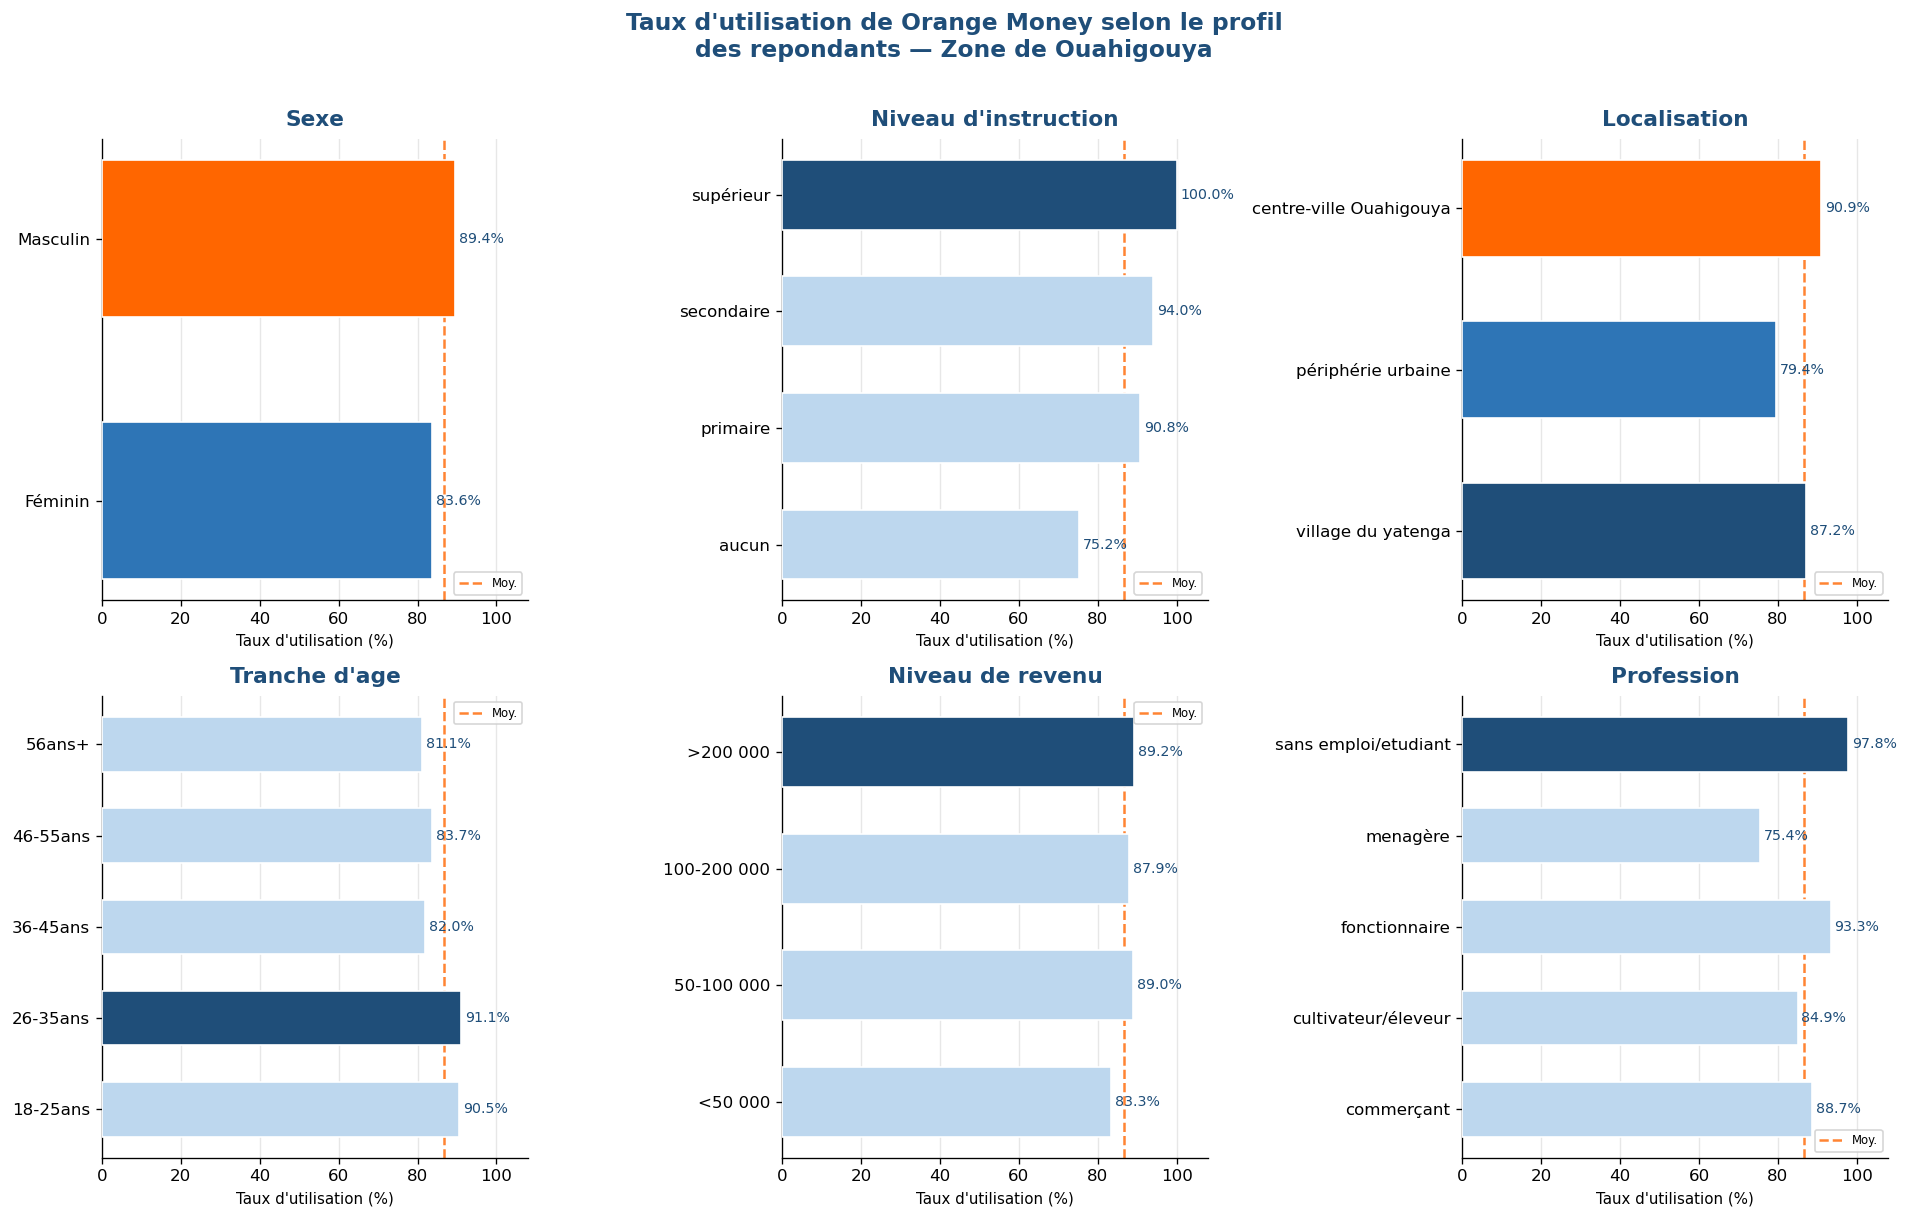

Sauvegarde : fig1_taux_adoption_profil.png


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Taux d'utilisation de Orange Money selon le profil\ndes repondants — Zone de Ouahigouya",
             fontsize=14, fontweight='bold', color=BLUE_DARK, y=1.01)
configs = [
    ('sexe',         'Sexe',               None,         [BLUE_MID, ORANGE]),
    ('instruction',  "Niveau d'instruction",ORDER_INST,  None),
    ('localisation', 'Localisation',        ORDER_LOC,   [BLUE_DARK, BLUE_MID, ORANGE]),
    ('age_cat',      "Tranche d'age",       ORDER_AGE,   None),
    ('revenu_cat',   'Niveau de revenu',    ORDER_REVENU, None),
    ('profession',   'Profession',           None,        None),
]
for ax, (var, title, order, palette) in zip(axes.flat, configs):
    grp = df.groupby(var)['Y_utilisation'].mean() * 100
    if order:
        grp = grp.reindex([o for o in order if o in grp.index])
    cats  = list(grp.index)
    vals  = list(grp.values)
    colors = palette[:len(cats)] if palette else [BLUE_DARK if v==max(vals) else BLUE_LIGHT for v in vals]
    bars = ax.barh(cats, vals, color=colors, edgecolor='white', height=0.6, zorder=3)
    ax.set_xlim(0, 108); ax.set_title(title, pad=8, color=BLUE_DARK)
    ax.set_xlabel("Taux d'utilisation (%)", fontsize=9)
    ax.axvline(df['Y_utilisation'].mean()*100, color=ORANGE, ls='--', lw=1.5, alpha=0.8, label='Moy.')
    ax.grid(axis='x', alpha=0.3, zorder=0)
    for bar, val in zip(bars, vals):
        ax.text(val+1, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=8.5, color=BLUE_DARK)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig1_taux_adoption_profil.png")
plt.show()
print("Sauvegarde : fig1_taux_adoption_profil.png")


## Cellule 11 — Figure 2 : Scores Likert comparés

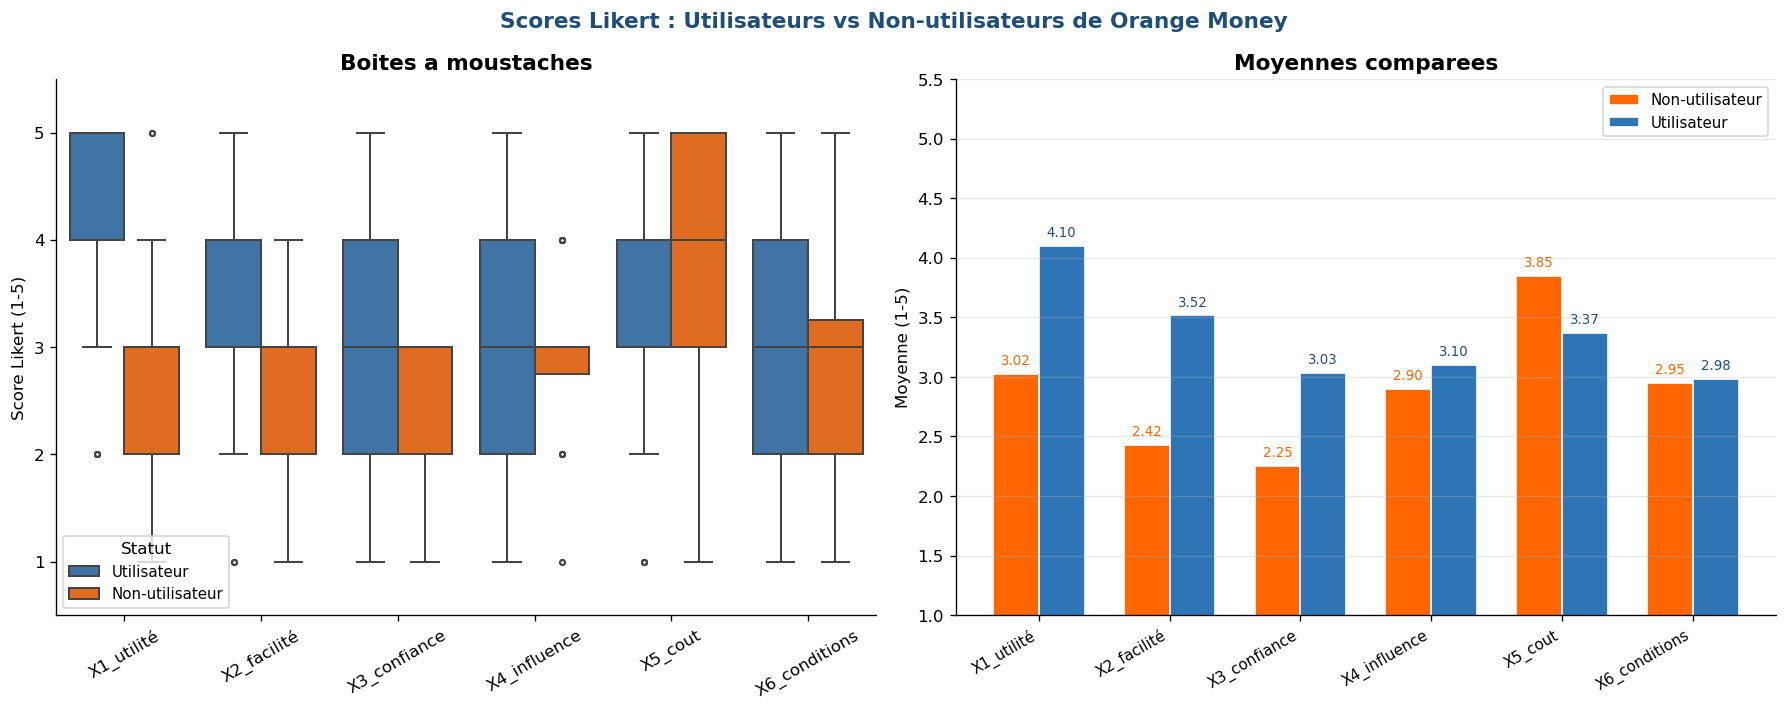

Sauvegarde : fig2_likert_comparaison.png


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Scores Likert : Utilisateurs vs Non-utilisateurs de Orange Money",
             fontsize=13, fontweight='bold', color=BLUE_DARK)

long_df = df.melt(id_vars=['Y_utilisation'], value_vars=COLS_LIKERT,
                  var_name='Variable', value_name='Score')
long_df['Variable'] = long_df['Variable'].map({k: v[:20] for k, v in LABELS_LIKERT.items()})
long_df['Statut']   = long_df['Y_utilisation'].map({1: 'Utilisateur', 0: 'Non-utilisateur'})

sns.boxplot(data=long_df, x='Variable', y='Score', hue='Statut',
            palette={'Utilisateur': BLUE_MID, 'Non-utilisateur': ORANGE},
            ax=axes[0], linewidth=1.2, fliersize=3)
axes[0].set_title("Boites a moustaches"); axes[0].set_xlabel("")
axes[0].set_ylabel("Score Likert (1-5)"); axes[0].tick_params(axis='x', rotation=30)
axes[0].set_ylim(0.5, 5.5); axes[0].legend(title='Statut', fontsize=9)

means = df.groupby('Y_utilisation')[COLS_LIKERT].mean()
means.index   = ['Non-utilisateur', 'Utilisateur']
means.columns = [LABELS_LIKERT[c][:18] for c in COLS_LIKERT]
x = np.arange(len(means.columns)); w = 0.35
axes[1].bar(x-w/2, means.loc['Non-utilisateur'], w, color=ORANGE, label='Non-utilisateur', edgecolor='white')
axes[1].bar(x+w/2, means.loc['Utilisateur'],     w, color=BLUE_MID, label='Utilisateur', edgecolor='white')
axes[1].set_xticks(x); axes[1].set_xticklabels(means.columns, rotation=30, ha='right', fontsize=9)
axes[1].set_title("Moyennes comparees"); axes[1].set_ylabel("Moyenne (1-5)")
axes[1].set_ylim(1, 5.5); axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.3)
for i, (u, nu) in enumerate(zip(means.loc['Utilisateur'], means.loc['Non-utilisateur'])):
    axes[1].text(i+w/2, u+0.08, f'{u:.2f}', ha='center', fontsize=8, color=BLUE_DARK)
    axes[1].text(i-w/2, nu+0.08, f'{nu:.2f}', ha='center', fontsize=8, color=ORANGE)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig2_likert_comparaison.png")
plt.show()
print("Sauvegarde : fig2_likert_comparaison.png")


## Cellule 12 — Figure 3 : Matrice de corrélation

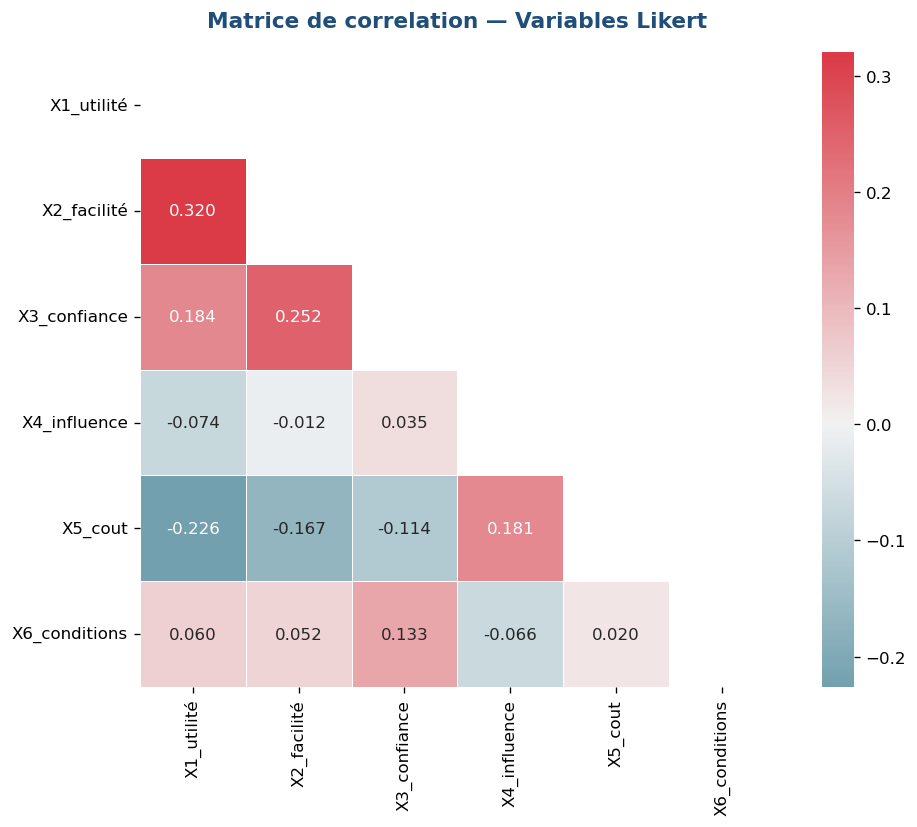

Sauvegarde : fig3_matrice_correlation.png


In [28]:
corr_plot = df[COLS_LIKERT].corr()
labels_c  = [LABELS_LIKERT[c] for c in COLS_LIKERT]
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones(corr_plot.shape, dtype=bool))
sns.heatmap(corr_plot, mask=mask, annot=True, fmt='.3f',
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            center=0, ax=ax, square=True, linewidths=0.5,
            xticklabels=labels_c, yticklabels=labels_c,
            annot_kws={'size': 10})
ax.set_title("Matrice de correlation — Variables Likert",
             fontsize=13, fontweight='bold', color=BLUE_DARK, pad=15)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig3_matrice_correlation.png")
plt.show()
print("Sauvegarde : fig3_matrice_correlation.png")


## Cellule 13 — Figure 4 : Odds Ratios (graphique en forêt)

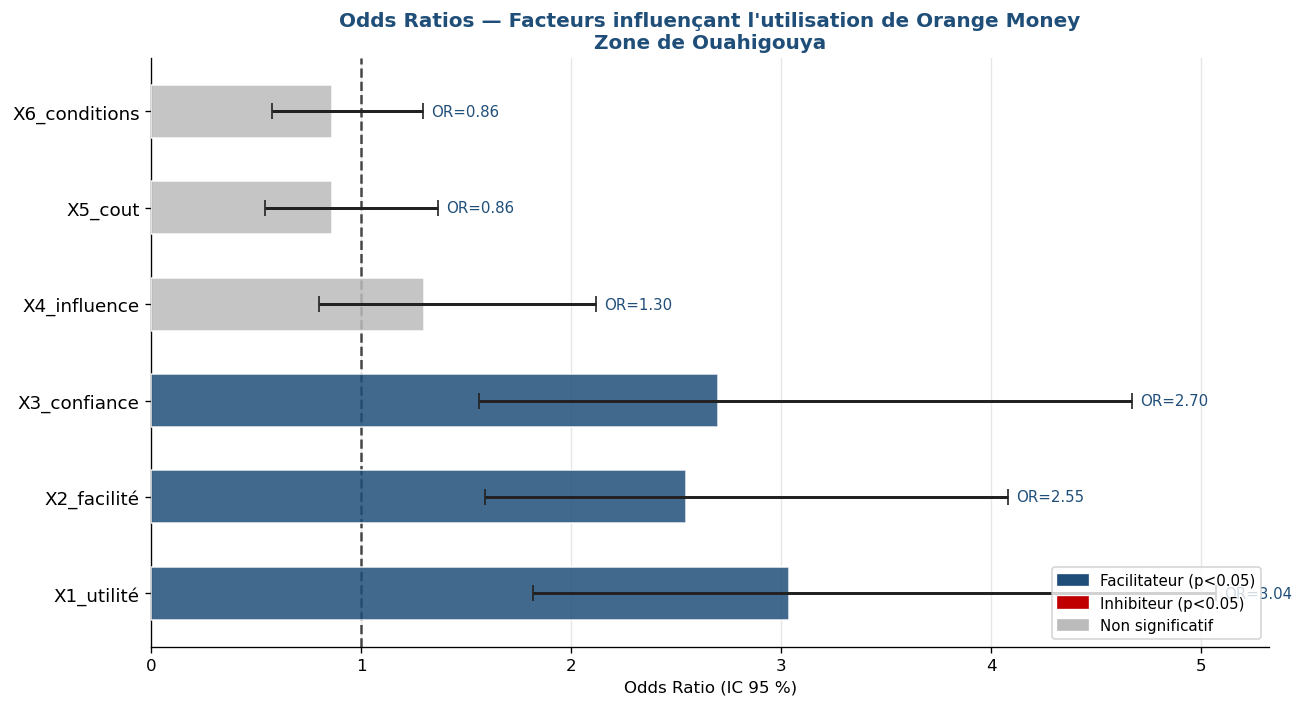

Sauvegarde : fig4_odds_ratios.png


In [29]:
keys_p = [k for k in OR.index if k != 'const']
y_pos  = np.arange(len(keys_p))
cols_or = [BLUE_DARK if (pvals[k]<0.05 and OR[k]>1)
           else RED   if (pvals[k]<0.05 and OR[k]<=1)
           else '#BBBBBB' for k in keys_p]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(y_pos, [OR[k] for k in keys_p], color=cols_or, edgecolor='white',
        height=0.55, zorder=3, alpha=0.85)
ax.errorbar([OR[k] for k in keys_p], y_pos,
            xerr=[[OR[k]-CI_lo[k] for k in keys_p],[CI_hi[k]-OR[k] for k in keys_p]],
            fmt='none', color='#222222', capsize=5, lw=1.8, zorder=4)
ax.axvline(1, color='black', lw=1.5, ls='--', alpha=0.7)
ax.set_yticks(y_pos); ax.set_yticklabels([noms.get(k,k) for k in keys_p], fontsize=11)
ax.set_xlabel("Odds Ratio (IC 95 %)"); ax.grid(axis='x', alpha=0.3, zorder=0)
ax.set_title("Odds Ratios — Facteurs influençant l'utilisation de Orange Money\nZone de Ouahigouya",
             fontsize=12, fontweight='bold', color=BLUE_DARK)
for i, k in enumerate(keys_p):
    ax.text(CI_hi[k]+0.04, i, f"OR={OR[k]:.2f}", va='center', fontsize=9, color=BLUE_DARK)
ax.legend(handles=[
    mpatches.Patch(color=BLUE_DARK, label='Facilitateur (p<0.05)'),
    mpatches.Patch(color=RED,       label='Inhibiteur (p<0.05)'),
    mpatches.Patch(color='#BBBBBB', label='Non significatif'),
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig4_odds_ratios.png")
plt.show()
print("Sauvegarde : fig4_odds_ratios.png")


## Cellule 14 — Figure 5 : Analyses croisées

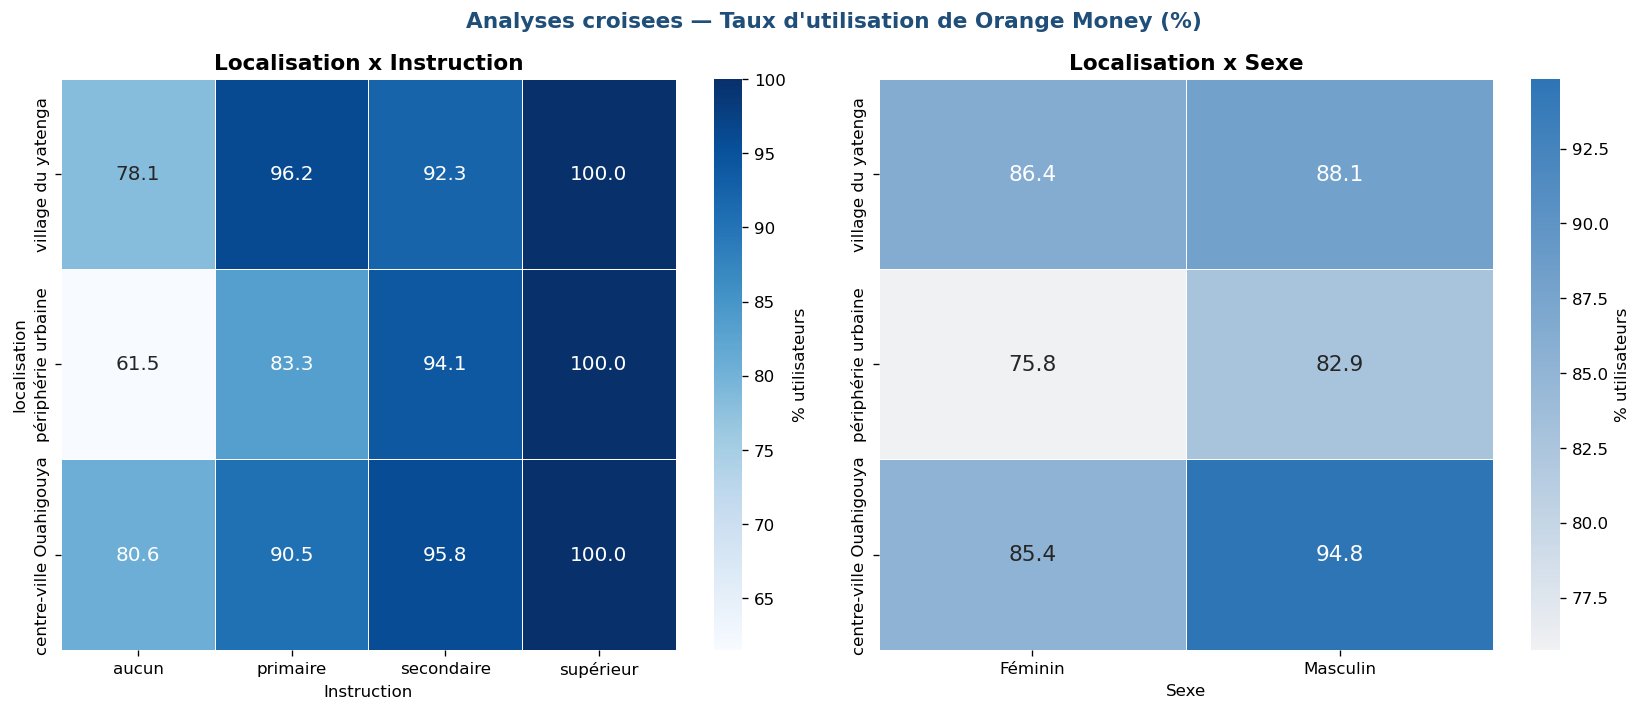

Sauvegarde : fig5_analyses_croisees.png


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Analyses croisees — Taux d'utilisation de Orange Money (%)",
             fontsize=13, fontweight='bold', color=BLUE_DARK)

pivot_li = df.pivot_table('Y_utilisation','localisation','instruction',aggfunc='mean')*100
pivot_li = pivot_li.reindex(columns=[c for c in ORDER_INST if c in pivot_li.columns])
pivot_li = pivot_li.reindex(index=[r for r in ORDER_LOC if r in pivot_li.index])
sns.heatmap(pivot_li, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            linewidths=0.5, cbar_kws={'label':'% utilisateurs'}, annot_kws={'size':12})
axes[0].set_title("Localisation x Instruction"); axes[0].set_xlabel("Instruction")

pivot_ls = df.pivot_table('Y_utilisation','localisation','sexe',aggfunc='mean')*100
pivot_ls = pivot_ls.reindex(index=[r for r in ORDER_LOC if r in pivot_ls.index])
sns.heatmap(pivot_ls, annot=True, fmt='.1f',
            cmap=sns.light_palette(BLUE_MID, as_cmap=True), ax=axes[1],
            linewidths=0.5, cbar_kws={'label':'% utilisateurs'}, annot_kws={'size':13})
axes[1].set_title("Localisation x Sexe"); axes[1].set_xlabel("Sexe"); axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig5_analyses_croisees.png")
plt.show()
print("Sauvegarde : fig5_analyses_croisees.png")


## Cellule 15 — Figure 6 : Fréquence d'utilisation

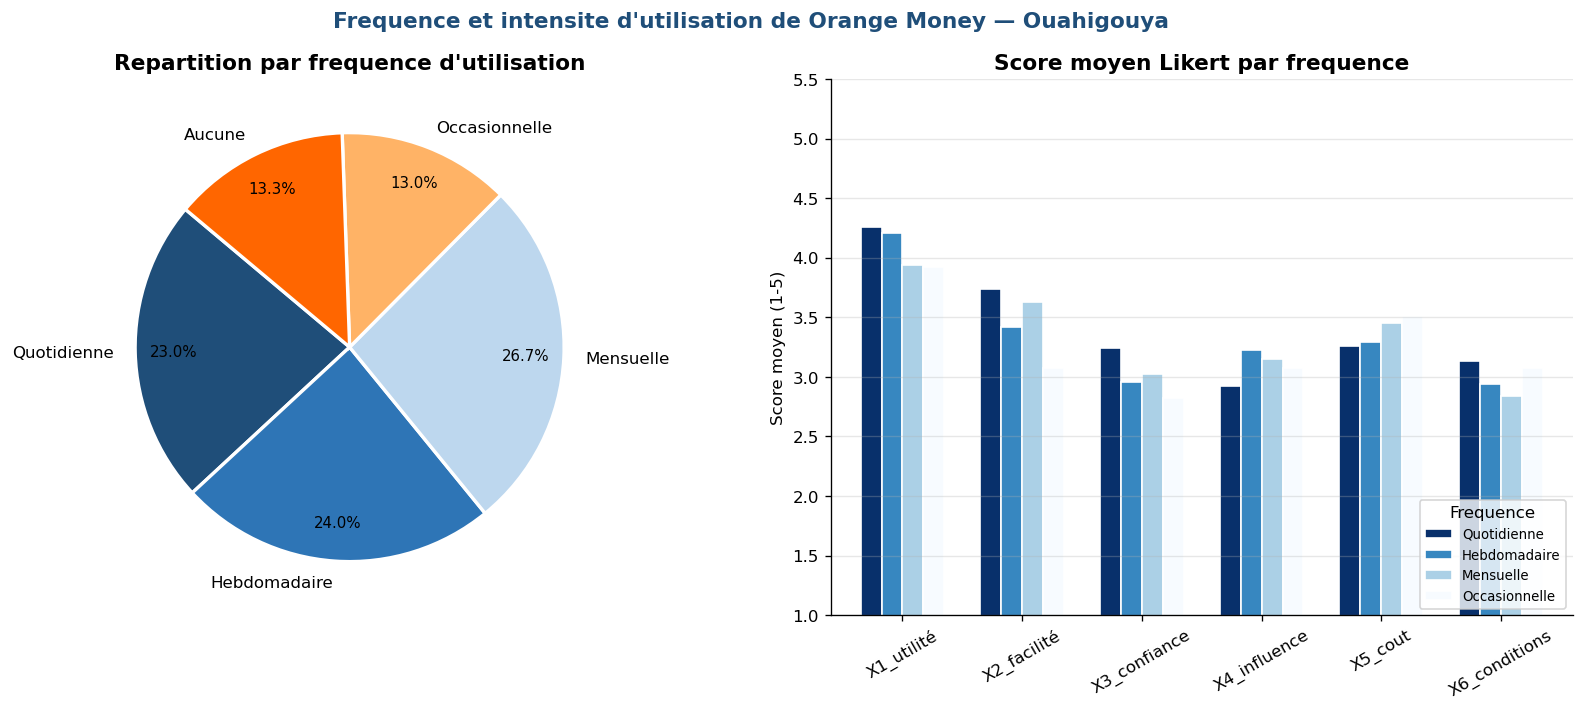

Sauvegarde : fig6_frequence_utilisation.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Frequence et intensite d'utilisation de Orange Money — Ouahigouya",
             fontsize=13, fontweight='bold', color=BLUE_DARK)

fc  = df['frequence'].value_counts()
fo  = fc.reindex([f for f in ORDER_FREQ if f in fc.index])
colors_f = [BLUE_DARK, BLUE_MID, BLUE_LIGHT, ORANGE_L, ORANGE]
_, _, autotexts = axes[0].pie(
    fo.values, labels=fo.index, colors=colors_f[:len(fo)],
    autopct='%1.1f%%', pctdistance=0.82, startangle=140,
    wedgeprops={'edgecolor':'white','linewidth':2})
for at in autotexts: at.set_fontsize(9)
axes[0].set_title("Repartition par frequence d'utilisation")

util_df2    = df[df['Y_utilisation'] == 1].copy()
fm          = util_df2.groupby('frequence')[COLS_LIKERT].mean()
fm          = fm.reindex([f for f in ORDER_FREQ[:4] if f in fm.index])
fm.columns  = [LABELS_LIKERT[c][:14] for c in COLS_LIKERT]
fm.T.plot(kind='bar', ax=axes[1], colormap='Blues_r', edgecolor='white', width=0.7)
axes[1].set_title("Score moyen Likert par frequence")
axes[1].set_ylabel("Score moyen (1-5)"); axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Frequence', fontsize=8, loc='lower right')
axes[1].grid(axis='y', alpha=0.3); axes[1].set_ylim(1, 5.5)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/fig6_frequence_utilisation.png")
plt.show()
print("Sauvegarde : fig6_frequence_utilisation.png")


## Cellule 16 — Figure 7 : Tableau de bord général

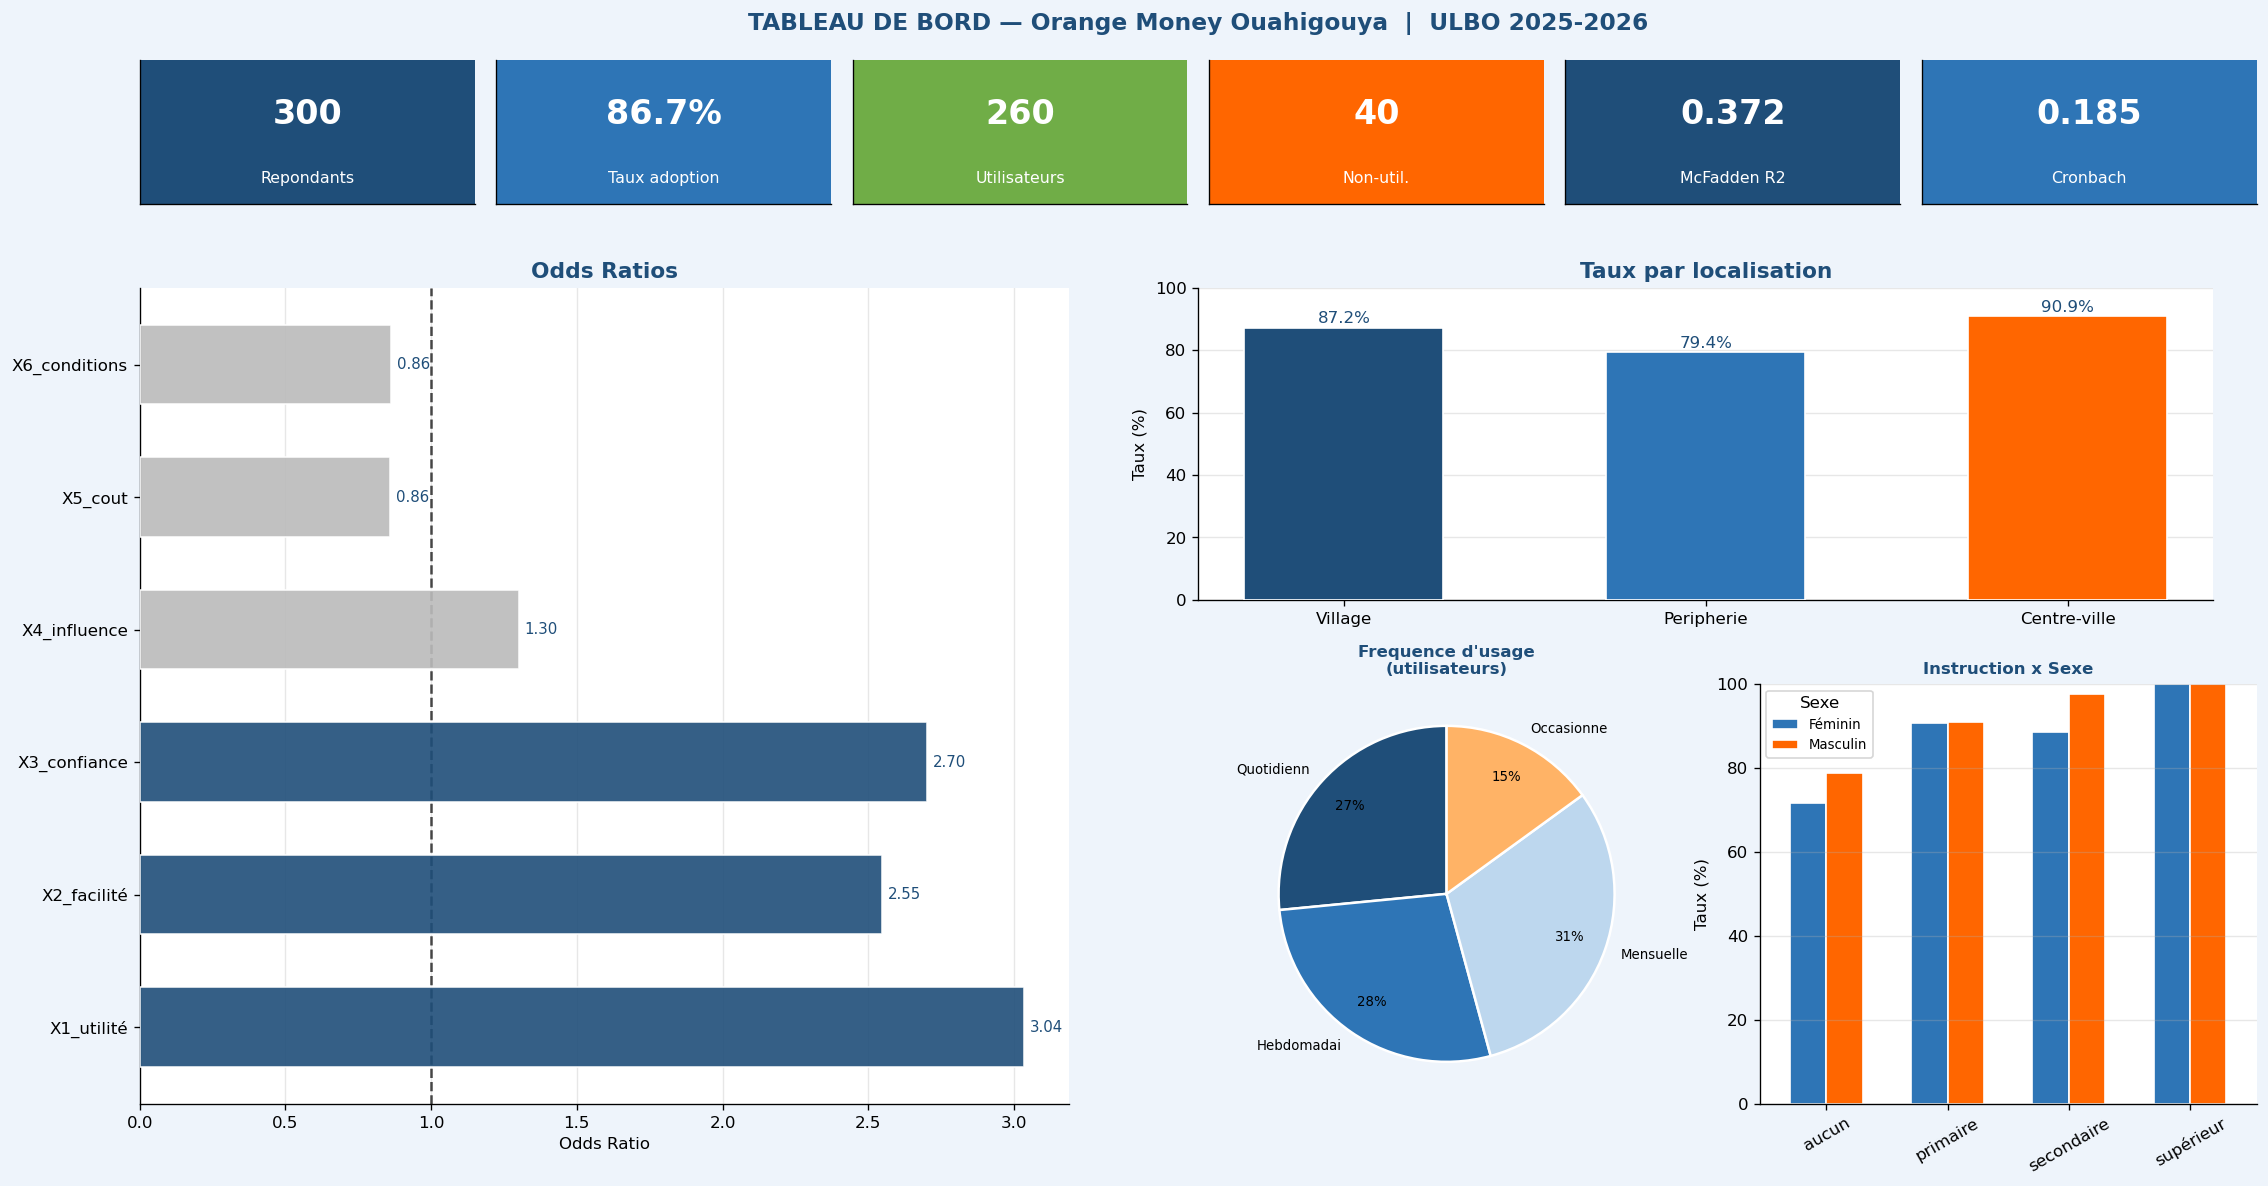

Sauvegarde : fig7_tableau_de_bord.png


In [32]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#EEF4FB')
fig.suptitle("TABLEAU DE BORD — Orange Money Ouahigouya  |  ULBO 2025-2026",
             fontsize=14, fontweight='bold', color=BLUE_DARK, y=0.99)

n_t  = len(df); n_u = df['Y_utilisation'].sum()
k_   = len(COLS_LIKERT)
alph = (k_/(k_-1))*(1 - df[COLS_LIKERT].var().sum()/df[COLS_LIKERT].sum(axis=1).var())
kpis = [("Repondants", str(n_t), BLUE_DARK), ("Taux adoption", f"{n_u/n_t*100:.1f}%", BLUE_MID),
        ("Utilisateurs", str(n_u), GREEN),    ("Non-util.", str(n_t-n_u), ORANGE),
        ("McFadden R2", f"{result.prsquared:.3f}", BLUE_DARK), ("Cronbach", f"{alph:.3f}", BLUE_MID)]
for i, (label, val, col) in enumerate(kpis):
    ax_k = fig.add_axes([0.01+i*0.165, 0.83, 0.155, 0.12])
    ax_k.set_facecolor(col)
    ax_k.text(0.5, 0.62, val, ha='center', va='center', fontsize=20,
              fontweight='bold', color='white', transform=ax_k.transAxes)
    ax_k.text(0.5, 0.18, label, ha='center', va='center', fontsize=9.5,
              color='white', transform=ax_k.transAxes)
    ax_k.set_xticks([]); ax_k.set_yticks([])

ax1 = fig.add_axes([0.01, 0.08, 0.43, 0.68])
kp  = [k for k in OR.index if k != 'const']
co  = [BLUE_DARK if (pvals[k]<0.05 and OR[k]>1) else RED if (pvals[k]<0.05 and OR[k]<=1) else '#BBBBBB' for k in kp]
ax1.barh([noms.get(k,k) for k in kp], [OR[k] for k in kp],
         color=co, edgecolor='white', height=0.6, zorder=3, alpha=0.9)
ax1.axvline(1, color='black', lw=1.5, ls='--', alpha=0.7)
ax1.set_xlabel("Odds Ratio"); ax1.set_title("Odds Ratios", fontweight='bold', color=BLUE_DARK)
ax1.grid(axis='x', alpha=0.3); ax1.set_facecolor('white')
for i, k in enumerate(kp): ax1.text(OR[k]+0.02, i, f'{OR[k]:.2f}', va='center', fontsize=9, color=BLUE_DARK)

ax2 = fig.add_axes([0.50, 0.50, 0.47, 0.26])
lt  = df.groupby('localisation')['Y_utilisation'].mean()*100
lt  = lt.reindex(ORDER_LOC)
ax2.bar(range(3), lt.values, color=[BLUE_DARK, BLUE_MID, ORANGE], edgecolor='white', zorder=3, width=0.55)
ax2.set_xticks(range(3)); ax2.set_xticklabels(['Village','Peripherie','Centre-ville'], fontsize=10)
ax2.set_ylabel("Taux (%)"); ax2.set_title("Taux par localisation", fontweight='bold', color=BLUE_DARK)
ax2.grid(axis='y', alpha=0.3); ax2.set_facecolor('white'); ax2.set_ylim(0, 100)
for i, v in enumerate(lt.values): ax2.text(i, v+1.5, f'{v:.1f}%', ha='center', fontsize=10, color=BLUE_DARK)

ax3 = fig.add_axes([0.50, 0.08, 0.23, 0.35])
uf  = df[df['Y_utilisation']==1]['frequence'].value_counts()
uf  = uf.reindex([f for f in ORDER_FREQ[:4] if f in uf.index])
ax3.pie(uf.values, labels=[f[:10] for f in uf.index],
        colors=[BLUE_DARK,BLUE_MID,BLUE_LIGHT,ORANGE_L],
        autopct='%1.0f%%', startangle=90, pctdistance=0.78,
        wedgeprops={'edgecolor':'white','lw':1.5}, textprops={'fontsize':8})
ax3.set_title("Frequence d'usage\n(utilisateurs)", fontweight='bold', color=BLUE_DARK, fontsize=10)

ax4 = fig.add_axes([0.76, 0.08, 0.23, 0.35])
sp  = df.groupby(['instruction','sexe'])['Y_utilisation'].mean().unstack()*100
sp  = sp.reindex(ORDER_INST)
sp.plot(kind='bar', ax=ax4, color=[BLUE_MID,ORANGE], edgecolor='white', width=0.6)
ax4.set_title("Instruction x Sexe", fontweight='bold', color=BLUE_DARK, fontsize=10)
ax4.set_xlabel(""); ax4.set_ylabel("Taux (%)")
ax4.tick_params(axis='x', rotation=30); ax4.set_facecolor('white')
ax4.legend(title='Sexe', fontsize=8); ax4.grid(axis='y', alpha=0.3); ax4.set_ylim(0, 100)

plt.savefig(f"{OUTPUT_DIR}/fig7_tableau_de_bord.png", facecolor='#EEF4FB')
plt.show()
print("Sauvegarde : fig7_tableau_de_bord.png")


## Cellule 17 — Rapport de synthèse final

In [36]:
# ==========================================================
# SYNTHESE GENERALE DES RESULTATS
# ==========================================================

n = len(df)
n_util = int((df["Y_utilisation"] == 1).sum())
taux = (n_util / n) * 100

print("=" * 70)
print("SYNTHESE DES RESULTATS — ORANGE MONEY / OUAHIGOUYA")
print("=" * 70)

print("\n1. ECHANTILLON")
print(f"   Effectif total                : {n}")
print(f"   Taux d'utilisation            : {taux:.2f} %")

# ==========================================================
# CHI2
# ==========================================================

if "df_chi2" in globals():

    print("\n2. VARIABLES SOCIODEMOGRAPHIQUES (Chi²)")

    for _, row in df_chi2.iterrows():

        mark = "✓" if row["Sig."] != "n.s." else "-"

        print(f"   {mark} {row['Variable']:<25} p={row['p-value']:.4f}  {row['Sig.']}")

# ==========================================================
# LIKERT
# ==========================================================

if "df_likert" in globals():

    print("\n3. VARIABLES LIKERT")

    for _, row in df_likert.iterrows():

        mark = "✓" if row["Sig."] != "n.s." else "-"

        print(f"   {mark} {row['Variable']:<25} Diff={row['Difference']:+.3f}  {row['Sig.']}")

# ==========================================================
# REGRESSION
# ==========================================================

if "OR" in globals():

    print("\n4. REGRESSION LOGISTIQUE")

    for var in OR.index:

        if var == "const":
            continue

        p = pvals[var]

        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = "n.s."

        sens = "Facilitateur" if OR[var] > 1 else "Inhibiteur"

        print(f"   {var:<25} OR={OR[var]:.3f}   p={p:.4f}   {sig}   {sens}")

# ==========================================================
# QUALITE DU MODELE
# ==========================================================

if "result" in globals():

    print("\n5. QUALITE DU MODELE")

    print(f"   Pseudo R² (McFadden) : {result.prsquared:.4f}")

    print(f"   AIC                 : {result.aic:.2f}")

    print(f"   LLR p-value         : {result.llr_pvalue:.6f}")

# ==========================================================
# LOCALISATION
# ==========================================================

print("\n6. UTILISATION PAR LOCALISATION")

for loc in ORDER_LOC:

    sous_df = df[df["localisation"] == loc]

    if len(sous_df):

        taux_loc = sous_df["Y_utilisation"].mean()*100

        print(f"   {loc:<30} {taux_loc:.1f}%")

# ==========================================================
# SEXE
# ==========================================================

print("\n7. UTILISATION SELON LE SEXE")

for sexe in df["sexe"].dropna().unique():

    taux_sexe = df.loc[df["sexe"] == sexe, "Y_utilisation"].mean()*100

    print(f"   {sexe:<15} {taux_sexe:.1f}%")

# ==========================================================
# RECOMMANDATIONS
# ==========================================================

if "suggestions" in df.columns:

    print("\n8. RECOMMANDATIONS")

    aucune = (df["suggestions"].fillna("")=="Aucune").mean()*100

    print(f"   Aucune recommandation : {aucune:.1f}%")

    mots = {

        "plafond":"Augmenter le plafond",

        "reseau":"Améliorer le réseau",

        "frais":"Réduire les frais",

        "agence":"Multiplier les agences",

        "alphabet":"Alphabétisation",

        "fraude":"Lutter contre les fraudes",

        "promouvoir":"Promouvoir Orange Money"

    }

    for mot, libelle in mots.items():

        pct = df["suggestions"].fillna("").str.contains(mot,case=False).mean()*100

        print(f"   {libelle:<30} {pct:.1f}%")

print("\n" + "="*70)
print("ANALYSE TERMINEE AVEC SUCCES")
print("="*70)

SYNTHESE DES RESULTATS — ORANGE MONEY / OUAHIGOUYA

1. ECHANTILLON
   Effectif total                : 300
   Taux d'utilisation            : 86.67 %

2. VARIABLES SOCIODEMOGRAPHIQUES (Chi²)
   - Sexe                      p=0.1919  n.s.
   - Tranche d'age             p=0.3004  n.s.
   ✓ Niveau d'instruction      p=0.0000  ***
   ✓ Profession                p=0.0106  *
   - Niveau de revenu          p=0.6121  n.s.
   - Localisation              p=0.0966  n.s.
   ✓ Type de telephone         p=0.0001  ***

3. VARIABLES LIKERT
   ✓ X1_utilité                Diff=+1.071  ***
   ✓ X2_facilité               Diff=+1.090  ***
   ✓ X3_confiance              Diff=+0.785  ***
   - X4_influence              Diff=+0.200  n.s.
   ✓ X5_cout                   Diff=-0.485  **
   - X6_conditions             Diff=+0.031  n.s.

4. REGRESSION LOGISTIQUE
   X1                        OR=3.036   p=0.0000   ***   Facilitateur
   X2                        OR=2.546   p=0.0001   ***   Facilitateur
   X3            